# Lab 3: Feature Selection by Caleb Christian

## Part 1

Question 1:

I believe determining the best model comes from looking at the actual predictors and seeing the correlations between them would actually imrpove the model or just be unneeded predictors bringing in redundant info. This is similar to my answer from last week but just an imrpoved answer including multicolinearity.

Question 2:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

In [3]:
peng = pd.read_csv("C:\\Users\\chair\\DS6021_F26\\data\\penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

bike = pd.read_csv("C:\\Users\\chair\\DS6021_F26\\data\\bike-sharing-daily.csv", parse_dates=["dteday"])

In [5]:
bike[["cnt", "temp", "hum", "windspeed"]].corr()



,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


<Axes: >

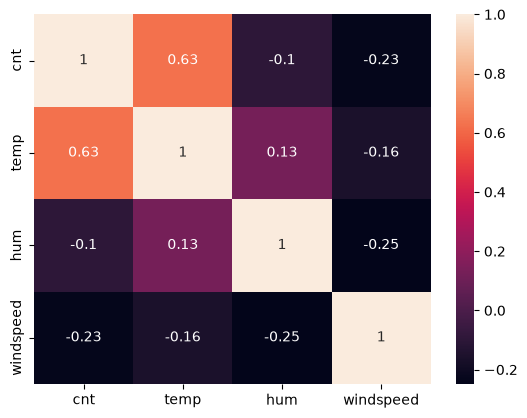

In [6]:
sns.heatmap(
    bike[["cnt", "temp", "hum", "windspeed"]].corr(),
    annot=True
)

In [44]:
b_model = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()

b_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        20:31:10   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.000    3421.061    4747.665
temp        6625.5327    293.085     22.606      0.000    6050.138    7200.927
hum        -3100.1231    383.992     -8.073      0.000   -3853.988   -2346.258
windspeed  -4806.9293    708.904     -6.781      0.000   -6198.673   -3415.186
==============================================================================
Omnibus:                       11.001   Durbin-Watson:                   0.404
Prob(Omnibus):                  0.004   Jarque-Bera (JB):                8.213
Skew:                           0.152   Prob(JB):                       0.0165
Kurtosis:                       2.579   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
def vif_table(model):
    X = model.model.exog
    names = model.model.exog_names

    vif = pd.DataFrame({
        "variable": names,
        "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    })

    return vif

vif_table(b_model)

,variable,VIF
0,Intercept,41.075299
1,temp,1.034283
2,hum,1.074850
3,windspeed,1.084580


So it seems using the Ols model, we can see that the predictor temp has a positive correlation with the bike rentals unlike the other 2 predictors hum and windspeed. However we do see that all 3 are significant. This makes sense because if the weather is good and warm, people want to ride bikes. If the weather is bad with humidity and a lot of wind, then no one wants to ride bikes.

In [10]:
from statsmodels.stats.anova import anova_lm

In [12]:
bmodel1 = smf.ols("cnt ~ temp", data=bike).fit()
bmodel2 = smf.ols("cnt ~ temp + hum", data=bike).fit()
bmodel3 = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()

In [13]:
anova_lm(bmodel1, bmodel2, bmodel3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,729.0,1.660847e+09,0.0,NaN,NaN,NaN
1,728.0,1.570304e+09,1.0,9.054330e+07,44.569779,4.869005e-11
2,727.0,1.476897e+09,1.0,9.340630e+07,45.979085,2.475445e-11


I think I would choose the model with the most predictors. As we saw earlier with the OLS model and the VIF and now with this F-test, we can see that model3(the model with the most predictors) has the highest F score.

## Part 2

Question 1:

In [5]:
pengno_sex = peng.dropna(subset=["sex"]).reset_index(drop=True)
pmodel1 = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=peng
).fit()

pmodel2 = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=pengno_sex
).fit()

In [ ]:
pmodel1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.26e-103
Time:                        16:09:31   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6445.4760    566.130    -11.385      0.000   -7559.167   -5331.785
flipper_length_mm    50.7621      2.497     20.327      0.000      45.850      55.675
bill_depth_mm        17.8364     13.826      1.290      0.198      -9.362      45.035
bill_length_mm        3.2929      5.366      0.614      0.540      -7.263      13.849
==============================================================================
Omnibus:                        5.596   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.061   Jarque-Bera (JB):                5.469
Skew:                           0.312   Prob(JB):                       0.0649
Kurtosis:                       3.068   Cond. No.                     5.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
pmodel2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.26e-103
Time:                        16:09:54   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6445.4760    566.130    -11.385      0.000   -7559.167   -5331.785
flipper_length_mm    50.7621      2.497     20.327      0.000      45.850      55.675
bill_depth_mm        17.8364     13.826      1.290      0.198      -9.362      45.035
bill_length_mm        3.2929      5.366      0.614      0.540      -7.263      13.849
==============================================================================
Omnibus:                        5.596   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.061   Jarque-Bera (JB):                5.469
Skew:                           0.312   Prob(JB):                       0.0649
Kurtosis:                       3.068   Cond. No.                     5.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

There is no change at all between the two models. I think this just means that the sexes dont affect the results as much.

Question 2:

In [8]:
pmodel_base = smf.ols(
    "body_mass_g ~ flipper_length_mm",
    data=pengno_sex
).fit()

pmodel_add = smf.ols(
    "body_mass_g ~ flipper_length_mm + C(sex)",
    data=pengno_sex
).fit()

pmodel_int = smf.ols(
    "body_mass_g ~ flipper_length_mm * C(sex)",
    data=pengno_sex
).fit()

In [11]:
anova_lm(pmodel_base, pmodel_add, pmodel_int)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,331.0,5.121196e+07,0.0,NaN,NaN,NaN
1,330.0,4.179537e+07,1.0,9.416589e+06,74.126700,3.050629e-16
2,329.0,4.179409e+07,1.0,1.286001e+03,0.010123,9.199177e-01


In [12]:
pmodel_base.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.13e-105
Time:                        16:36:11   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.285    -18.925      0.000   -6482.472   -5261.713
flipper_length_mm    50.1533      1.540     32.562      0.000      47.123      53.183
==============================================================================
Omnibus:                        5.922   Durbin-Watson:                   2.116
Prob(Omnibus):                  0.052   Jarque-Bera (JB):                5.876
Skew:                           0.325   Prob(JB):                       0.0530
Kurtosis:                       3.025   Cond. No.                     2.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
pmodel_add.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.53e-118
Time:                        16:36:25   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.798    -18.931      0.000   -5972.515   -4848.085
C(sex)[T.male]      347.8503     40.342      8.623      0.000     268.491     427.209
flipper_length_mm    46.9822      1.441     32.598      0.000      44.147      49.817
==============================================================================
Omnibus:                        0.262   Durbin-Watson:                   1.710
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.376
Skew:                           0.051   Prob(JB):                        0.829
Kurtosis:                       2.870   Cond. No.                     2.95e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.95e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
pmodel_int.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     455.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.04e-116
Time:                        16:36:35   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4862.
Df Residuals:                     329   BIC:                             4878.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                        -5443.9607    440.283    -12.365      0.000   -6310.086   -4577.836
C(sex)[T.male]                     406.8015    587.303      0.693      0.489    -748.541    1562.144
flipper_length_mm                   47.1527      2.226     21.179      0.000      42.773      51.532
flipper_length_mm:C(sex)[T.male]    -0.2942      2.924     -0.101      0.920      -6.047       5.458
==============================================================================
Omnibus:                        0.262   Durbin-Watson:                   1.711
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.375
Skew:                           0.051   Prob(JB):                        0.829
Kurtosis:                       2.871   Cond. No.                     8.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

I am going to choose model 2 or aka the additive model that compares body mass to flipper lenght and sex. They have the highest adjusted r-squared and F metric between the 3 models

Again looking at the additive model, we can see that the coeffecient for the t.male is significant according to the p-value. We can see that according to the coefficient, the male penguins have about 347.85 grams more than females.

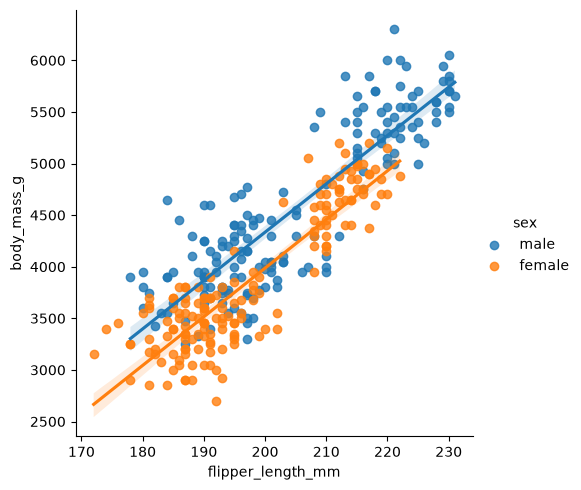

In [15]:
sns.lmplot(
    data=pengno_sex,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="sex"
)

plt.show()

As you can see even the graph supports my conclusion that the males are heavier than the females. I chose this graph because you can see the difference in body mass and you can see based on the slopes how they would look and it seems that they are parallel. I can now confidently say that sex is a significant predictor for body mass.

Question 3:

In [16]:
pmodel_sp_add = smf.ols(
    "body_mass_g ~ C(sex) + C(species)",
    data=pengno_sex
).fit()

pmodel_sp_int = smf.ols(
    "body_mass_g ~ C(sex) * C(species)",
    data=pengno_sex
).fit()

In [17]:
pmodel_sp_add.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     606.1
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.27e-133
Time:                        17:04:09   Log-Likelihood:                -2387.8
No. Observations:                 333   AIC:                             4784.
Df Residuals:                     329   BIC:                             4799.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3372.3868     31.427    107.308      0.000    3310.563    3434.210
C(sex)[T.male]            667.5552     34.704     19.236      0.000     599.285     735.825
C(species)[T.Chinstrap]    26.9239     46.483      0.579      0.563     -64.518     118.366
C(species)[T.Gentoo]     1377.8580     39.104     35.236      0.000    1300.932    1454.784
==============================================================================
Omnibus:                        1.146   Durbin-Watson:                   2.113
Prob(Omnibus):                  0.564   Jarque-Bera (JB):                1.139
Skew:                          -0.034   Prob(JB):                        0.566
Kurtosis:                       2.722   Cond. No.                         3.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
pmodel_sp_int.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     384.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.54e-134
Time:                        17:07:19   Log-Likelihood:                -2379.1
No. Observations:                 333   AIC:                             4770.
Df Residuals:                     327   BIC:                             4793.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                               3368.8356     36.212     93.030      0.000    3297.597    3440.074
C(sex)[T.male]                           674.6575     51.212     13.174      0.000     573.911     775.404
C(species)[T.Chinstrap]                  158.3703     64.240      2.465      0.014      31.994     284.747
C(species)[T.Gentoo]                    1310.9058     54.422     24.088      0.000    1203.844    1417.968
C(sex)[T.male]:C(species)[T.Chinstrap]  -262.8928     90.849     -2.894      0.004    -441.616     -84.170
C(sex)[T.male]:C(species)[T.Gentoo]      130.4372     76.436      1.706      0.089     -19.930     280.805
==============================================================================
Omnibus:                        0.654   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.721   Jarque-Bera (JB):                0.748
Skew:                           0.001   Prob(JB):                        0.688
Kurtosis:                       2.768   Cond. No.                         9.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
anova_lm(pmodel_sp_add, pmodel_sp_int)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,329.0,3.297919e+07,0.0,NaN,NaN,NaN
1,327.0,3.130263e+07,2.0,1.676557e+06,8.756997,0.000197


I would choose the interactive model this time because looking at the adjusted r squared and the p-value for each coeffecient, they are more significant.

According to the model we know that the intercept is for the female adelie species, the male adeilie species weight about 674.65 more than the females, the female chinstrap weigh 158.37 more than the female adeile, the female gentoo weigh 1310.91 more than the female adelie, the chinstrap species has a 262.89 smaller difference in weight(based on sex) compared to the adeilie species and the gentoo species has a 130.44 bigger difference in weight(based on sex) compared to the adeile species .

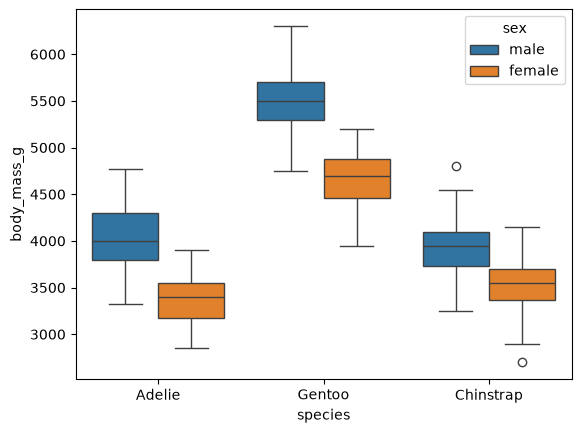

In [21]:
sns.boxplot(
    data=pengno_sex,
    x="species",
    y="body_mass_g",
    hue="sex"
)

plt.show()

I chose this type of graph because of the categories. We are dealing with categorical variables so a boxplot made more sense. I could have done a scatter plot again and made the dots different colors based on race but it wouldnt make sense since we are also comparing sex. The boxplot shows that the body mass does differ when it comes to sex and species. Also the visual differences between the Chinstrap species support my earlier claims.

Question 4:

In [24]:
bmodel_add = smf.ols(
    "casual ~ temp + C(workingday) + hum + windspeed",
    data=bike
).fit()

bmodel_int = smf.ols(
    "casual ~ temp * C(workingday) + hum + windspeed",
    data=bike
).fit()

In [25]:
bmodel_add.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 casual   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     307.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.84e-155
Time:                        18:08:29   Log-Likelihood:                -5448.9
No. Observations:                 731   AIC:                         1.091e+04
Df Residuals:                     726   BIC:                         1.093e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1063.5527    101.370     10.492      0.000     864.540    1262.566
C(workingday)[T.1]  -806.6343     33.410    -24.143      0.000    -872.226    -741.042
temp                2149.5173     86.324     24.901      0.000    1980.043    2318.991
hum                 -812.7411    112.979     -7.194      0.000   -1034.545    -590.937
windspeed          -1145.3093    208.554     -5.492      0.000   -1554.750    -735.869
==============================================================================
Omnibus:                      108.341   Durbin-Watson:                   0.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              241.630
Skew:                           0.820   Prob(JB):                     3.39e-53
Kurtosis:                       5.290   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
bmodel_int.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 casual   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     307.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          2.25e-176
Time:                        18:08:36   Log-Likelihood:                -5395.6
No. Observations:                 731   AIC:                         1.080e+04
Df Residuals:                     725   BIC:                         1.083e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 492.5703    108.430      4.543      0.000     279.696     705.445
C(workingday)[T.1]         68.4230     87.703      0.780      0.436    -103.759     240.605
temp                     3354.7267    138.592     24.206      0.000    3082.638    3626.815
temp:C(workingday)[T.1] -1792.4490    167.989    -10.670      0.000   -2122.252   -1462.646
hum                      -840.4351    105.137     -7.994      0.000   -1046.844    -634.026
windspeed               -1102.3863    194.061     -5.681      0.000   -1483.375    -721.398
==============================================================================
Omnibus:                      120.077   Durbin-Watson:                   0.960
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              550.759
Skew:                           0.665   Prob(JB):                    2.54e-120
Kurtosis:                       7.039   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Ok so we can see that the int model is better than the additive model because if you look at the r squared it is higher here than the additive model. The interaction between working day and temp is significant if you look at the p-value.

In [27]:
bmodel_add = smf.ols(
    "registered ~ temp + C(workingday) + hum + windspeed",
    data=bike
).fit()

bmodel_int = smf.ols(
    "registered ~ temp * C(workingday) + hum + windspeed",
    data=bike
).fit()

In [28]:
bmodel_add.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             registered   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     134.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.97e-86
Time:                        18:21:27   Log-Likelihood:                -6208.8
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     726   BIC:                         1.245e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286.657     10.276      0.000    2383.041    3508.591
C(workingday)[T.1]   932.4392     94.478      9.869      0.000     746.956    1117.922
temp                4460.1902    244.109     18.271      0.000    3980.947    4939.434
hum                -2294.0896    319.485     -7.181      0.000   -2921.314   -1666.866
windspeed          -3656.3914    589.755     -6.200      0.000   -4814.220   -2498.563
==============================================================================
Omnibus:                       27.507   Durbin-Watson:                   0.341
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.374
Skew:                           0.146   Prob(JB):                     0.000756
Kurtosis:                       2.378   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
bmodel_int.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             registered   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     108.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.89e-85
Time:                        18:21:30   Log-Likelihood:                -6207.4
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     725   BIC:                         1.245e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3215.1761    329.195      9.767      0.000    2568.886    3861.466
C(workingday)[T.1]        519.6323    266.268      1.952      0.051      -3.116    1042.381
temp                     3891.6346    420.767      9.249      0.000    3065.568    4717.701
temp:C(workingday)[T.1]   845.5850    510.018      1.658      0.098    -155.703    1846.873
hum                     -2281.0250    319.198     -7.146      0.000   -2907.687   -1654.363
windspeed               -3676.6403    589.172     -6.240      0.000   -4833.328   -2519.953
==============================================================================
Omnibus:                       26.830   Durbin-Watson:                   0.341
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.322
Skew:                           0.152   Prob(JB):                     0.000776
Kurtosis:                       2.386   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Ok so the models predicting registered users have a lower r squared and f-statistic than the models predicting the casual users. We can see also in the interaction, that it is not significant. We can see that registered users would use bikes on working days and causal users would use bikes for non working days.

I think the reason you had us do this was to see that the original model did not factor in who were the types of people or user renting the bikes. The original model was just showing the rentals all together and was not accounting for working days. We see that modeling the casual and registered users by itself gives a way better grasp of the total number of rentals. 

## Part 3

Question 1

In [30]:
pmodel1 = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=peng
).fit()

In [36]:
#using notebook from class:feature selection pt2
infl = OLSInfluence(pmodel1)
n, p = int(pmodel1.nobs), pmodel1.df_model
print(f"n = {n}, p = {p:.0f}")

diag = pd.DataFrame({
    "body_mass_g": peng.body_mass_g,
    "fitted": pmodel1.fittedvalues,
    "student_resid": infl.resid_studentized_external,
    "leverage": infl.hat_matrix_diag,
    "cooks_d": infl.cooks_distance[0],
})

diag.head(10)

n = 342, p = 3


,body_mass_g,fitted,student_resid,leverage,cooks_d
0,3750.0,3211.617868,1.376420,0.008831,0.004209
1,3800.0,3438.564312,0.921907,0.007306,0.001564
2,3250.0,3906.346483,-1.676699,0.004599,0.003230
3,3450.0,3816.889879,-0.938715,0.013330,0.002977
4,3650.0,3702.967340,-0.135413,0.014287,0.000067
5,3625.0,3192.740924,1.104655,0.009992,0.003077
6,4675.0,3933.847733,1.902148,0.011451,0.010398
7,3475.0,3782.009706,-0.786136,0.015675,0.002463
8,4250.0,3706.184442,1.391234,0.010026,0.004887
9,3300.0,3425.474357,-0.319884,0.008505,0.000220


In [ ]:
#also taken from class notebook
lev_cut, cook_cut = 2 * (p + 1) / n, 4 / n

print(f"leverage cutoff = {lev_cut:.4f}")
print(f"Cook's D cutoff = {cook_cut:.4f}")

print(f"outliers: {(diag.student_resid.abs() > 3).sum()}")
print(f"high leverage: {(diag.leverage > lev_cut).sum()}")
print(f"influential: {(diag.cooks_d > cook_cut).sum()}")

leverage cutoff = 0.0234
Cook's D cutoff = 0.0117
outliers: 1
high leverage: 10
influential: 13


In [39]:
diag["sex"] = peng["sex"]

missing_sex = diag[diag["sex"].isna()]

print(f"outliers: {(missing_sex.student_resid.abs() > 3).sum()}")
print(f"high leverage: {(missing_sex.leverage > lev_cut).sum()}")
print(f"influential: {(missing_sex.cooks_d > cook_cut).sum()}")

outliers: 0
high leverage: 0
influential: 0


Ok so we saw the leverge cutoff was 0.0234 and the cook d cutoff was 0.0117. We also saw there was 1 outlier, 10 high leverage penguins and 13 influential penguins. However paying attention to the 9 missing sex penguins, none of them exceeded the cutoffs.

No I believe that these findings completely support my findings from part 2. This makes sense as to why not including the 9 penguins didnt really change the model coefficients or p-values or f-statistics.

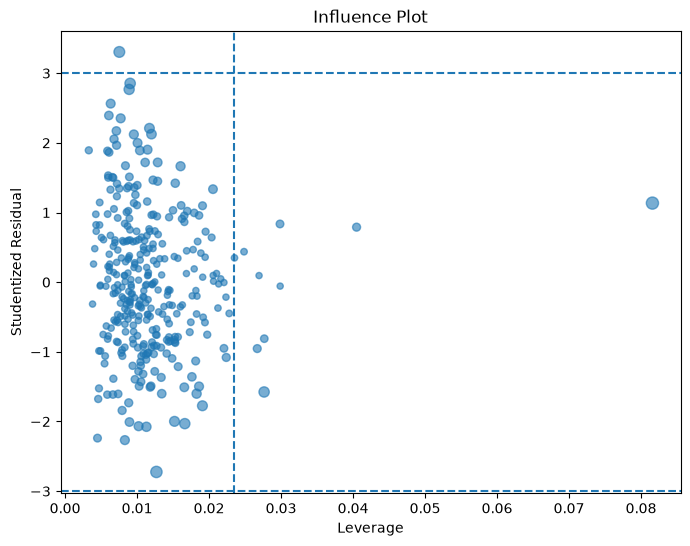

In [41]:
#used llm + class notebook to make the graph
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    diag["leverage"],
    diag["student_resid"],
    s=20 + 2000 * diag["cooks_d"],
    alpha=0.6
)

ax.axhline(3, linestyle="--")
ax.axhline(-3, linestyle="--")
ax.axvline(lev_cut, linestyle="--")

ax.set_xlabel("Leverage")
ax.set_ylabel("Studentized Residual")
ax.set_title("Influence Plot")

plt.show()

Ok according to the graph we can see that there is indeed an outlier all the way at the top which is exceeding the residual level of 3. We also see that there is an observation all the way to the right. Basically the plot is showing that most of the observations are closely packed and only a couple stand out.

Question 2:

In [46]:
#used llm and class notebook to create df
bike_sandy = bike[bike["dteday"] != "2012-10-29"]

bsandy = smf.ols(
    "cnt ~ temp + hum + windspeed",
    data=bike_sandy
).fit()

pd.DataFrame({
    "original": b_model.params,
    "without_sandy": bsandy.params
})

,original,without_sandy
Intercept,4084.363384,4027.426590
temp,6625.532710,6622.024728
hum,-3100.123135,-3038.957626
windspeed,-4806.929325,-4682.081768


In [47]:
bike_317 = bike[bike["dteday"] != "2012-03-17"]

bikerd = smf.ols(
    "cnt ~ temp + hum + windspeed",
    data=bike_317
).fit()

pd.DataFrame({
    "original": b_model.params,
    "without_317": bikerd.params
})

,original,without_317
Intercept,4084.363384,4082.512214
temp,6625.532710,6628.535478
hum,-3100.123135,-3121.765113
windspeed,-4806.929325,-4756.889369


When we remove hurricane sandy as an observation, we can see that every value decreased from the original model even if they were small decreases. When we remove that random date of 3/17/12, we can see thatthere were some even smaller decreases in all variables including intercept, temp, hum and windspeed. So realistically removing either of them does not really do anything. I would probably just keep them and tell the stakeholder the details/significance of these 2 specific dates.

## Part 4

Taking a general look at all 3 of these links you can tell they are helpful for making the best outcomes when it comes to data. In class earlier this month we took a look at linear models and comparing it to linear regression models. At the end of one of the labs I believe we took a quick peak at using log transformations which was stated would be something we would learn more about so I am excited about that. Another thing we did was using techniques from feature scaling like in class for the penguin dataset and the class dataset based on the survey we took. Basically these links were to help us understand why we are sort of learning the fundamentals for modeling because it plays hand in hand with machine learning. My questions would be "Is there ever such a thing as perfect data, as in we dont have to perform any standardization or any feature scaling techniques?" and "If we dont have to interpret the data rather predict it, what are the next steps to transform the data or would we have to at all?"